# 日线数据市场状态识别

本 Notebook 使用老师提供的 A 股日线数据，对市场状态进行识别。基本思路是先将个股日线数据聚合为市场层面的日度特征，例如等权收益率、滚动收益率、滚动波动率、上涨股票占比、截面波动率和成交额变化等；随后使用 Gaussian HMM 对市场进行状态划分，识别不同的 market regime。

本分析对应前期文献中的隐藏状态思想：

$$
X_t \rightarrow Z_t \rightarrow Y_t
$$

其中，$X_t$ 表示市场日线特征，$Z_t$ 表示识别出的市场状态，$Y_t$ 可以理解为后续收益率或涨跌方向预测目标。

In [17]:
# Cell 1：基础配置与路径设置

from pathlib import Path
import glob
import os
import re
import time
import warnings
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

warnings.filterwarnings("ignore")

# ========== 项目总目录 ==========
PROJECT_DIR = Path("/Users/runtianzhou/Turing_AI")

# ========== 分类保存目录 ==========
RAW_DIR = PROJECT_DIR / "data_raw"
EXTRACT_DIR = PROJECT_DIR / "data_extracted"
OUT_DIR = PROJECT_DIR / "state_recognition_output"
FIG_DIR = PROJECT_DIR / "figures"
REPORT_DIR = PROJECT_DIR / "reports"

for d in [RAW_DIR, EXTRACT_DIR, OUT_DIR, FIG_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ========== 原始压缩包路径 ==========
ARCHIVE_PATH = RAW_DIR / "daily_temp3.7z"

# 如果压缩包还在 Downloads 或 Desktop，自动寻找
candidate_paths = [
    ARCHIVE_PATH,
    Path("/Users/runtianzhou/Downloads/daily_temp3.7z"),
    Path("/Users/runtianzhou/Desktop/daily_temp3.7z"),
    Path("/Users/runtianzhou/daily_temp3.7z"),
]

found_path = None
for p in candidate_paths:
    if p.exists():
        found_path = p
        break

if found_path is None:
    raise FileNotFoundError(
        "没有找到 daily_temp3.7z。请把 daily_temp3.7z 放到 "
        "/Users/runtianzhou/Turing_AI/data_raw/ 里面，或者放到 Downloads/Desktop。"
    )

# 如果找到的文件不在 data_raw，就复制一份到 data_raw
if found_path != ARCHIVE_PATH:
    import shutil
    shutil.copy2(found_path, ARCHIVE_PATH)

print("PROJECT_DIR:", PROJECT_DIR)
print("ARCHIVE_PATH:", ARCHIVE_PATH)
print("EXTRACT_DIR:", EXTRACT_DIR)
print("OUT_DIR:", OUT_DIR)
print("FIG_DIR:", FIG_DIR)
print("REPORT_DIR:", REPORT_DIR)

PROJECT_DIR: /Users/runtianzhou/Turing_AI
ARCHIVE_PATH: /Users/runtianzhou/Turing_AI/data_raw/daily_temp3.7z
EXTRACT_DIR: /Users/runtianzhou/Turing_AI/data_extracted
OUT_DIR: /Users/runtianzhou/Turing_AI/state_recognition_output
FIG_DIR: /Users/runtianzhou/Turing_AI/figures
REPORT_DIR: /Users/runtianzhou/Turing_AI/reports


In [18]:
# Cell 2：解压 7z 文件

def ensure_py7zr():
    try:
        import py7zr
        return True
    except ImportError:
        print("py7zr 未安装，正在尝试安装 py7zr ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "py7zr", "-q"])
            import py7zr
            return True
        except Exception as e:
            print("自动安装 py7zr 失败：", e)
            return False


def extract_7z(archive_path: Path, extract_dir: Path):
    csv_files = list(extract_dir.rglob("*.csv")) if extract_dir.exists() else []
    if len(csv_files) > 0:
        print(f"已经发现 {len(csv_files)} 个 CSV 文件，跳过解压。")
        return

    if not archive_path.exists():
        raise FileNotFoundError("没有找到 daily_temp3.7z。请把压缩包放到当前目录，或修改 ARCHIVE_PATH。")

    extract_dir.mkdir(parents=True, exist_ok=True)

    if not ensure_py7zr():
        raise RuntimeError("无法安装或导入 py7zr。请手动解压 daily_temp3.7z 后，再设置 EXTRACT_DIR。")

    import py7zr
    print("开始解压：", archive_path)
    with py7zr.SevenZipFile(archive_path, mode="r") as z:
        z.extractall(path=extract_dir)
    print("解压完成。")


extract_7z(ARCHIVE_PATH, EXTRACT_DIR)

csv_files = sorted(EXTRACT_DIR.rglob("*.csv"))
print("CSV 文件数量：", len(csv_files))
print("前 5 个文件：")
for f in csv_files[:5]:
    print(" -", f)

开始解压： /Users/runtianzhou/Turing_AI/data_raw/daily_temp3.7z
解压完成。
CSV 文件数量： 1476
前 5 个文件：
 - /Users/runtianzhou/Turing_AI/data_extracted/daily_temp3/20200102.csv
 - /Users/runtianzhou/Turing_AI/data_extracted/daily_temp3/20200103.csv
 - /Users/runtianzhou/Turing_AI/data_extracted/daily_temp3/20200106.csv
 - /Users/runtianzhou/Turing_AI/data_extracted/daily_temp3/20200107.csv
 - /Users/runtianzhou/Turing_AI/data_extracted/daily_temp3/20200108.csv


In [19]:
# Cell 3：读取 CSV 并聚合成市场日度特征

usecols = [
    "tradeDate", "chgPct", "turnoverValue", "turnoverRate",
    "preClosePrice", "highestPrice", "lowestPrice",
    "negMarketValue", "isOpen"
]


def read_csv_safely(path: Path, usecols):
    encodings = ["utf-8", "utf-8-sig", "gbk", "gb18030"]
    last_err = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, usecols=lambda c: c in usecols)
        except Exception as e:
            last_err = e
    raise last_err


def parse_date_from_df_or_name(df: pd.DataFrame, path: Path):
    if "tradeDate" in df.columns and len(df) > 0:
        raw = str(df["tradeDate"].iloc[0])
        return pd.to_datetime(raw, errors="coerce")

    m = re.search(r"(20\d{6})", path.stem)
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")
    return pd.NaT


rows = []
t0 = time.time()

for idx, f in enumerate(csv_files):
    try:
        df = read_csv_safely(f, usecols=usecols)
    except Exception as e:
        print("读取失败：", f, e)
        continue

    if "isOpen" in df.columns:
        df = df[df["isOpen"] == 1]

    num_cols = [
        "chgPct", "turnoverValue", "turnoverRate",
        "preClosePrice", "highestPrice", "lowestPrice", "negMarketValue"
    ]

    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "chgPct" not in df.columns:
        continue

    df = df.dropna(subset=["chgPct"])
    if df.empty:
        continue

    date = parse_date_from_df_or_name(df, f)
    if pd.isna(date):
        continue

    if "negMarketValue" in df.columns:
        w = df["negMarketValue"].fillna(0).clip(lower=0)
        if w.sum() > 0:
            vw_ret = np.average(df["chgPct"], weights=w)
        else:
            vw_ret = df["chgPct"].mean()
    else:
        vw_ret = df["chgPct"].mean()

    if all(c in df.columns for c in ["highestPrice", "lowestPrice", "preClosePrice"]):
        amp = ((df["highestPrice"] - df["lowestPrice"]) / df["preClosePrice"].replace(0, np.nan))
        amp = amp.replace([np.inf, -np.inf], np.nan)
        avg_amplitude = amp.mean()
    else:
        avg_amplitude = np.nan

    total_turnover_value = df["turnoverValue"].sum() if "turnoverValue" in df.columns else np.nan
    avg_turnover_rate = df["turnoverRate"].mean() if "turnoverRate" in df.columns else np.nan

    rows.append({
        "date": date,
        "n_stocks": len(df),
        "eq_ret": df["chgPct"].mean(),
        "vw_ret": vw_ret,
        "median_ret": df["chgPct"].median(),
        "cross_sec_vol": df["chgPct"].std(),
        "up_ratio": (df["chgPct"] > 0).mean(),
        "down_ratio": (df["chgPct"] < 0).mean(),
        "limit_up_ratio": (df["chgPct"] >= 0.095).mean(),
        "limit_down_ratio": (df["chgPct"] <= -0.095).mean(),
        "avg_amplitude": avg_amplitude,
        "total_turnover_value": total_turnover_value,
        "avg_turnover_rate": avg_turnover_rate,
    })

    if (idx + 1) % 300 == 0:
        print(f"已读取 {idx + 1} 个文件，用时 {time.time() - t0:.1f} 秒")

market_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

print("市场日度特征原始形状：", market_df.shape)
print("日期范围：", market_df["date"].min(), "到", market_df["date"].max())

market_df.head()

已读取 300 个文件，用时 2.0 秒
已读取 600 个文件，用时 4.2 秒
已读取 900 个文件，用时 6.5 秒
已读取 1200 个文件，用时 8.8 秒
市场日度特征原始形状： (1476, 13)
日期范围： 2020-01-02 00:00:00 到 2026-02-02 00:00:00


,date,n_stocks,eq_ret,vw_ret,median_ret,cross_sec_vol,up_ratio,down_ratio,limit_up_ratio,limit_down_ratio,avg_amplitude,total_turnover_value,avg_turnover_rate
0,2020-01-02,3740,0.018477,0.014561,0.0141,0.020569,0.906952,0.075401,0.024332,0.000267,0.031255,7.512655e+11,0.031552
1,2020-01-03,3741,0.005422,0.001038,0.0021,0.022595,0.547715,0.393210,0.017910,0.001871,0.030087,6.952152e+11,0.032059
2,2020-01-06,3743,0.007729,0.002300,0.0025,0.029729,0.550094,0.397008,0.022976,0.001336,0.037067,8.038776e+11,0.035760
3,2020-01-07,3743,0.013591,0.009369,0.0098,0.022522,0.801229,0.178734,0.022976,0.000534,0.031180,7.321135e+11,0.034508
4,2020-01-08,3742,-0.013230,-0.011562,-0.0182,0.026100,0.192678,0.796366,0.015232,0.001603,0.036945,7.790306e+11,0.036613


In [8]:
# Cell 4：构造状态识别特征

feat = market_df.copy()

feat["log_turnover"] = np.log(feat["total_turnover_value"].replace(0, np.nan))
feat["turnover_chg_5"] = feat["log_turnover"].diff(5)

feat["ret_5d"] = feat["eq_ret"].rolling(5).sum()
feat["ret_20d"] = feat["eq_ret"].rolling(20).sum()
feat["vol_20d"] = feat["eq_ret"].rolling(20).std()

feat["up_ratio_5d"] = feat["up_ratio"].rolling(5).mean()
feat["amplitude_5d"] = feat["avg_amplitude"].rolling(5).mean()

feat["turnover_level_z20"] = (
    feat["log_turnover"] - feat["log_turnover"].rolling(20).mean()
) / feat["log_turnover"].rolling(20).std()

feat["index_proxy"] = (1 + feat["eq_ret"].fillna(0)).cumprod()

feat.to_csv(OUT_DIR / "market_daily_features.csv", index=False, encoding="utf-8-sig")

print("特征构造完成：", feat.shape)
feat.tail()

特征构造完成： (1476, 22)


,date,n_stocks,eq_ret,vw_ret,median_ret,cross_sec_vol,up_ratio,down_ratio,limit_up_ratio,limit_down_ratio,...,avg_turnover_rate,log_turnover,turnover_chg_5,ret_5d,ret_20d,vol_20d,up_ratio_5d,amplitude_5d,turnover_level_z20,index_proxy
1471,2026-01-27,5173,-0.001294,0.001271,-0.0063,0.028269,0.358786,0.625749,0.017205,0.000967,...,0.043650,28.693912,0.041302,0.018704,0.091896,0.009033,0.519214,0.041002,0.111957,3.417607
1472,2026-01-28,5173,-0.004762,0.002658,-0.0106,0.052592,0.315291,0.668858,0.021071,0.003673,...,0.041475,28.717928,0.131223,0.006231,0.088615,0.009178,0.467821,0.041381,0.170061,3.401333
1473,2026-01-29,5174,-0.007020,0.000780,-0.0093,0.036207,0.332045,0.649981,0.020874,0.005025,...,0.044874,28.803415,0.182299,-0.009276,0.083151,0.009443,0.403897,0.043827,0.640746,3.377457
1474,2026-01-30,5171,-0.002492,-0.007839,-0.0019,0.031903,0.456391,0.522723,0.014891,0.014311,...,0.041669,28.673139,-0.084425,-0.026458,0.078837,0.009548,0.351965,0.045632,-0.474166,3.369039
1475,2026-02-02,5173,-0.023672,-0.023742,-0.0209,0.032173,0.142664,0.849604,0.008892,0.033250,...,0.038424,28.580547,-0.228462,-0.039240,0.038338,0.010874,0.321035,0.045172,-1.294429,3.289286


In [20]:
# Cell 5：自定义 Gaussian HMM

class GaussianHMMDiag:
    def __init__(self, n_states=4, n_iter=60, tol=1e-5, random_state=42, min_covar=1e-4):
        self.n_states = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.random_state = random_state
        self.min_covar = min_covar

    def _log_gaussian_prob(self, X):
        T, D = X.shape
        K = self.n_states
        logp = np.empty((T, K))

        for k in range(K):
            cov = np.maximum(self.covars_[k], self.min_covar)
            diff = X - self.means_[k]
            logp[:, k] = -0.5 * (
                D * np.log(2 * np.pi)
                + np.sum(np.log(cov))
                + np.sum(diff * diff / cov, axis=1)
            )

        return logp

    def _forward_backward(self, X):
        T = X.shape[0]
        K = self.n_states

        logB = self._log_gaussian_prob(X)
        logA = np.log(np.maximum(self.transmat_, 1e-300))
        logpi = np.log(np.maximum(self.startprob_, 1e-300))

        log_alpha = np.empty((T, K))
        log_beta = np.empty((T, K))

        log_alpha[0] = logpi + logB[0]

        for t in range(1, T):
            log_alpha[t] = logB[t] + logsumexp(log_alpha[t - 1][:, None] + logA, axis=0)

        log_likelihood = logsumexp(log_alpha[-1])

        log_beta[-1] = 0

        for t in range(T - 2, -1, -1):
            log_beta[t] = logsumexp(
                logA + logB[t + 1][None, :] + log_beta[t + 1][None, :],
                axis=1
            )

        gamma = np.exp(log_alpha + log_beta - log_likelihood)

        xi = np.zeros((K, K))
        for t in range(T - 1):
            xi += np.exp(
                log_alpha[t][:, None]
                + logA
                + logB[t + 1][None, :]
                + log_beta[t + 1][None, :]
                - log_likelihood
            )

        return log_likelihood, gamma, xi

    def fit(self, X):
        X = np.asarray(X)
        K = self.n_states

        gmm = GaussianMixture(
            n_components=K,
            covariance_type="diag",
            n_init=10,
            random_state=self.random_state,
            max_iter=500,
        ).fit(X)

        labels = gmm.predict(X)

        self.means_ = gmm.means_.copy()
        self.covars_ = gmm.covariances_.copy() + self.min_covar

        self.startprob_ = np.ones(K) / K
        self.startprob_[labels[0]] += 1
        self.startprob_ /= self.startprob_.sum()

        A = np.ones((K, K)) * 1e-2
        for a, b in zip(labels[:-1], labels[1:]):
            A[a, b] += 1
        self.transmat_ = A / A.sum(axis=1, keepdims=True)

        prev_ll = -np.inf
        self.loglik_history_ = []

        for it in range(self.n_iter):
            ll, gamma, xi = self._forward_backward(X)
            self.loglik_history_.append(ll)

            self.startprob_ = gamma[0] + 1e-8
            self.startprob_ /= self.startprob_.sum()

            self.transmat_ = xi + 1e-6
            self.transmat_ /= self.transmat_.sum(axis=1, keepdims=True)

            weights = gamma.sum(axis=0) + 1e-8
            self.means_ = (gamma.T @ X) / weights[:, None]

            for k in range(K):
                diff = X - self.means_[k]
                self.covars_[k] = (gamma[:, k][:, None] * diff * diff).sum(axis=0) / weights[k]
                self.covars_[k] += self.min_covar

            if it > 0 and abs(ll - prev_ll) < self.tol * max(1, abs(prev_ll)):
                print(f"HMM 收敛：iter={it}, loglik={ll:.2f}")
                break

            prev_ll = ll

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        _, gamma, _ = self._forward_backward(X)
        return gamma

    def predict(self, X):
        X = np.asarray(X)
        T = X.shape[0]
        K = self.n_states

        logB = self._log_gaussian_prob(X)
        logA = np.log(np.maximum(self.transmat_, 1e-300))
        logpi = np.log(np.maximum(self.startprob_, 1e-300))

        delta = np.empty((T, K))
        psi = np.zeros((T, K), dtype=int)

        delta[0] = logpi + logB[0]

        for t in range(1, T):
            vals = delta[t - 1][:, None] + logA
            psi[t] = np.argmax(vals, axis=0)
            delta[t] = np.max(vals, axis=0) + logB[t]

        states = np.empty(T, dtype=int)
        states[-1] = np.argmax(delta[-1])

        for t in range(T - 2, -1, -1):
            states[t] = psi[t + 1, states[t + 1]]

        return states

In [21]:
# Cell 6：训练 HMM 并识别市场状态

model_cols = [
    "eq_ret",
    "ret_5d",
    "ret_20d",
    "vol_20d",
    "up_ratio_5d",
    "cross_sec_vol",
    "amplitude_5d",
    "turnover_chg_5",
]

mdf = feat.dropna(subset=model_cols).copy().reset_index(drop=True)

scaler = StandardScaler()
X = scaler.fit_transform(mdf[model_cols].values)

N_STATES = 4

hmm = GaussianHMMDiag(
    n_states=N_STATES,
    n_iter=80,
    random_state=42
).fit(X)

mdf["state_raw"] = hmm.predict(X)

state_prob = hmm.predict_proba(X)

for k in range(N_STATES):
    mdf[f"state_prob_{k}"] = state_prob[:, k]

print("HMM 训练完成。")
print("样本数：", len(mdf))
print("状态数量：", N_STATES)

mdf[["date", "eq_ret", "ret_20d", "vol_20d", "up_ratio", "state_raw"]].head()

HMM 收敛：iter=9, loglik=-12180.04
HMM 训练完成。
样本数： 1457
状态数量： 4


,date,eq_ret,ret_20d,vol_20d,up_ratio,state_raw
0,2020-02-06,0.026220,-0.026289,0.024935,0.904914,0
1,2020-02-07,0.012353,-0.032413,0.024716,0.605417,0
2,2020-02-10,0.016169,-0.021665,0.024992,0.759225,0
3,2020-02-11,-0.004259,-0.033653,0.024913,0.362696,0
4,2020-02-12,0.017874,-0.029371,0.025070,0.838770,0


In [22]:
# Cell 7：汇总状态统计并给状态命名

summary = mdf.groupby("state_raw").agg(
    days=("date", "count"),
    start_date=("date", "min"),
    end_date=("date", "max"),
    mean_eq_ret=("eq_ret", "mean"),
    mean_ret_5d=("ret_5d", "mean"),
    mean_ret_20d=("ret_20d", "mean"),
    vol_20d=("vol_20d", "mean"),
    up_ratio=("up_ratio", "mean"),
    up_ratio_5d=("up_ratio_5d", "mean"),
    cross_sec_vol=("cross_sec_vol", "mean"),
    amplitude=("avg_amplitude", "mean"),
    avg_turnover_rate=("avg_turnover_rate", "mean"),
    log_turnover=("log_turnover", "mean"),
    limit_up_ratio=("limit_up_ratio", "mean"),
    limit_down_ratio=("limit_down_ratio", "mean"),
).reset_index()

labels = {}

ret_rank = summary.set_index("state_raw")["mean_ret_20d"].rank().to_dict()
vol_rank = summary.set_index("state_raw")["vol_20d"].rank().to_dict()
breadth_rank = summary.set_index("state_raw")["up_ratio_5d"].rank().to_dict()

median_abs_ret20 = abs(summary["mean_ret_20d"]).median()

for _, r in summary.iterrows():
    k = int(r["state_raw"])

    if ret_rank[k] <= 2 and vol_rank[k] >= 3:
        labels[k] = "高波动下跌/风险释放状态"

    elif ret_rank[k] >= 3 and breadth_rank[k] >= 3:
        labels[k] = "趋势上涨/赚钱效应状态"

    elif vol_rank[k] <= 2 and abs(r["mean_ret_20d"]) < median_abs_ret20 * 1.8:
        labels[k] = "低波动震荡/均衡状态"

    else:
        labels[k] = "高活跃切换/结构分化状态"

mdf["state_label"] = mdf["state_raw"].map(labels)
summary["state_label"] = summary["state_raw"].map(labels)

for col in [
    "mean_eq_ret", "mean_ret_5d", "mean_ret_20d", "vol_20d",
    "up_ratio", "up_ratio_5d", "cross_sec_vol", "amplitude",
    "avg_turnover_rate", "limit_up_ratio", "limit_down_ratio"
]:
    summary[col + "_pct"] = summary[col] * 100

summary_display = summary[[
    "state_raw",
    "state_label",
    "days",
    "mean_eq_ret_pct",
    "mean_ret_20d_pct",
    "vol_20d_pct",
    "up_ratio_pct",
    "cross_sec_vol_pct",
    "amplitude_pct"
]].copy()

summary_display = summary_display.rename(columns={
    "state_raw": "状态编号",
    "state_label": "状态解释",
    "days": "天数",
    "mean_eq_ret_pct": "日均等权收益(%)",
    "mean_ret_20d_pct": "20日累计收益(%)",
    "vol_20d_pct": "20日波动率(%)",
    "up_ratio_pct": "上涨股票占比(%)",
    "cross_sec_vol_pct": "截面波动率(%)",
    "amplitude_pct": "平均振幅(%)",
})

summary_display

,状态编号,状态解释,天数,日均等权收益(%),20日累计收益(%),20日波动率(%),上涨股票占比(%),截面波动率(%),平均振幅(%)
0,0,高波动下跌/风险释放状态,183,0.155931,1.675166,2.308056,50.846587,5.704715,5.341041
1,1,低波动震荡/均衡状态,518,0.210755,3.921103,0.928055,48.308779,3.857628,3.569730
2,2,低波动震荡/均衡状态,431,-0.401774,-1.455827,1.226466,39.803055,2.879881,3.960107
3,3,趋势上涨/赚钱效应状态,325,0.542858,3.055720,1.628409,56.089234,2.805041,3.859920


In [23]:
# Cell 8：生成状态区间 episodes

episodes = []
start = 0

for i in range(1, len(mdf)):
    if mdf.loc[i, "state_raw"] != mdf.loc[i - 1, "state_raw"]:
        seg = mdf.iloc[start:i]

        episodes.append({
            "state_raw": int(seg["state_raw"].iloc[0]),
            "state_label": seg["state_label"].iloc[0],
            "start_date": seg["date"].iloc[0],
            "end_date": seg["date"].iloc[-1],
            "days": len(seg),
            "cum_eq_ret": (1 + seg["eq_ret"]).prod() - 1,
            "avg_eq_ret": seg["eq_ret"].mean(),
            "avg_up_ratio": seg["up_ratio"].mean(),
        })

        start = i

seg = mdf.iloc[start:]

episodes.append({
    "state_raw": int(seg["state_raw"].iloc[0]),
    "state_label": seg["state_label"].iloc[0],
    "start_date": seg["date"].iloc[0],
    "end_date": seg["date"].iloc[-1],
    "days": len(seg),
    "cum_eq_ret": (1 + seg["eq_ret"]).prod() - 1,
    "avg_eq_ret": seg["eq_ret"].mean(),
    "avg_up_ratio": seg["up_ratio"].mean(),
})

episodes_df = pd.DataFrame(episodes)

episodes_df_display = episodes_df.copy()
episodes_df_display["cum_eq_ret"] = episodes_df_display["cum_eq_ret"] * 100
episodes_df_display["avg_eq_ret"] = episodes_df_display["avg_eq_ret"] * 100
episodes_df_display["avg_up_ratio"] = episodes_df_display["avg_up_ratio"] * 100

episodes_df_display.head(20)

,state_raw,state_label,start_date,end_date,days,cum_eq_ret,avg_eq_ret,avg_up_ratio
0,0,高波动下跌/风险释放状态,2020-02-06,2020-02-13,6,6.060036,0.993061,61.556502
1,3,趋势上涨/赚钱效应状态,2020-02-14,2020-02-14,1,0.166275,0.166275,44.170641
2,0,高波动下跌/风险释放状态,2020-02-17,2020-02-18,2,5.310010,2.624128,85.894040
3,3,趋势上涨/赚钱效应状态,2020-02-19,2020-02-20,2,1.227040,0.618419,58.339952
4,0,高波动下跌/风险释放状态,2020-02-21,2020-02-21,1,1.122354,1.122354,60.687831
5,3,趋势上涨/赚钱效应状态,2020-02-24,2020-02-25,2,1.025699,0.514133,43.242528
6,0,高波动下跌/风险释放状态,2020-02-26,2020-03-03,5,-1.211410,-0.194709,51.494652
7,3,趋势上涨/赚钱效应状态,2020-03-04,2020-03-11,6,0.677017,0.129627,51.622932
8,0,高波动下跌/风险释放状态,2020-03-12,2020-03-23,8,-9.937204,-1.283332,31.214871
9,3,趋势上涨/赚钱效应状态,2020-03-24,2020-03-30,5,0.678060,0.150228,52.162384


In [24]:
# Cell 9：保存结果文件

# 保存市场日度特征
feat.to_csv(OUT_DIR / "market_daily_features.csv", index=False, encoding="utf-8-sig")

# 保存 HMM 状态识别结果
mdf.to_csv(OUT_DIR / "hmm_state_result.csv", index=False, encoding="utf-8-sig")

# 保存状态统计汇总
summary.to_csv(OUT_DIR / "hmm_state_summary.csv", index=False, encoding="utf-8-sig")

# 保存连续状态区间
episodes_df.to_csv(OUT_DIR / "state_episodes.csv", index=False, encoding="utf-8-sig")

print("结果文件已保存到：", OUT_DIR)
print("- market_daily_features.csv")
print("- hmm_state_result.csv")
print("- hmm_state_summary.csv")
print("- state_episodes.csv")

结果文件已保存到： /Users/runtianzhou/Turing_AI/state_recognition_output
- market_daily_features.csv
- hmm_state_result.csv
- hmm_state_summary.csv
- state_episodes.csv


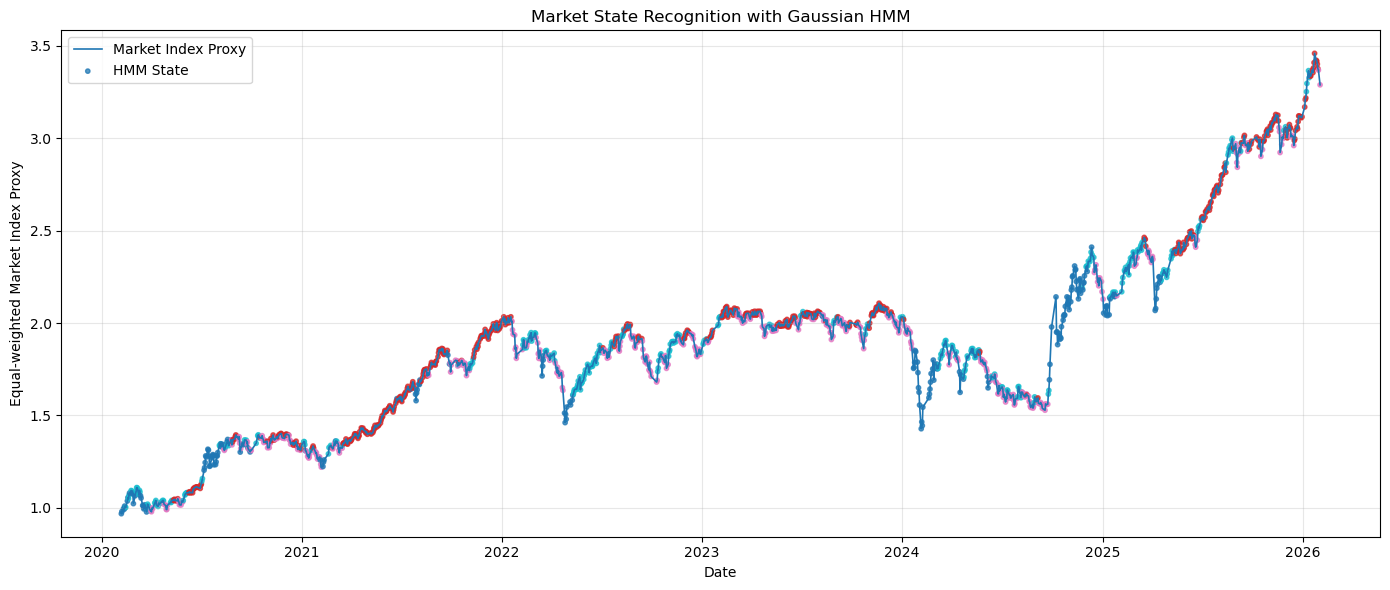

图像已保存： /Users/runtianzhou/Turing_AI/figures/market_state_timeline.png


In [25]:
# Cell 10：可视化市场状态时间线

plt.figure(figsize=(14, 6))

plt.plot(
    mdf["date"],
    mdf["index_proxy"],
    linewidth=1.2,
    label="Market Index Proxy"
)

plt.scatter(
    mdf["date"],
    mdf["index_proxy"],
    c=mdf["state_raw"],
    cmap="tab10",
    s=10,
    alpha=0.75,
    label="HMM State"
)

plt.title("Market State Recognition with Gaussian HMM")
plt.xlabel("Date")
plt.ylabel("Equal-weighted Market Index Proxy")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "market_state_timeline.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("图像已保存：", fig_path)

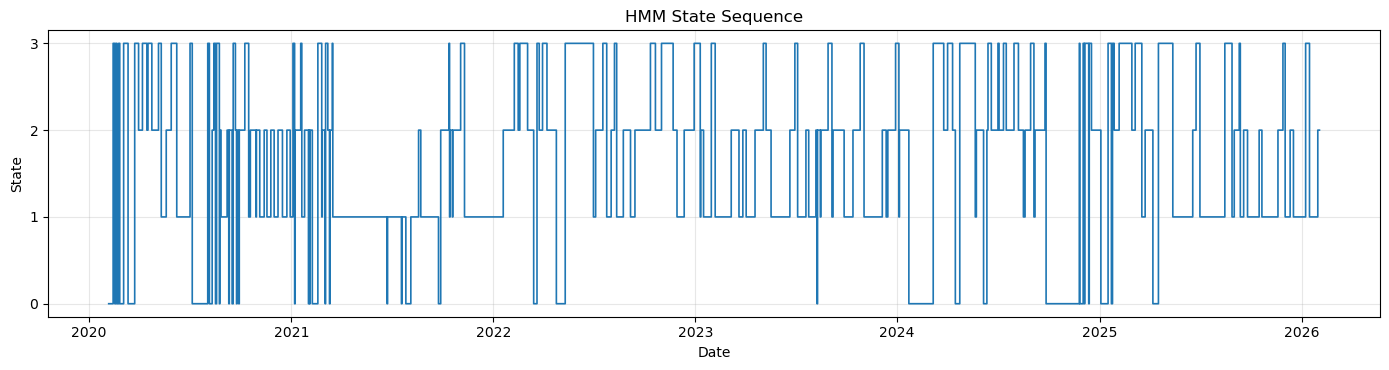

图像已保存： /Users/runtianzhou/Turing_AI/figures/state_sequence.png


In [26]:
# Cell 11：可视化状态序列

plt.figure(figsize=(14, 3.8))

plt.step(
    mdf["date"],
    mdf["state_raw"],
    where="post",
    linewidth=1.2
)

plt.title("HMM State Sequence")
plt.xlabel("Date")
plt.ylabel("State")
plt.yticks(sorted(mdf["state_raw"].unique()))
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "state_sequence.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("图像已保存：", fig_path)

In [27]:
# Cell 12：生成报告

report_lines = []

report_lines.append("# A股日线数据市场状态识别报告\n")
report_lines.append(f"样本区间：{mdf['date'].min().date()} 至 {mdf['date'].max().date()}\n")
report_lines.append(f"有效交易日数量：{len(mdf)}\n")

report_lines.append("\n## 一、方法说明\n")
report_lines.append(
    "本次分析先将全市场个股日线数据聚合为市场层面的日度特征，"
    "包括等权收益、20日累计收益、20日波动率、上涨股票占比、"
    "截面波动率、平均振幅和成交额变化等。随后使用4状态Gaussian HMM进行市场状态识别。\n"
)

report_lines.append("\n## 二、状态统计\n")

for _, r in summary_display.iterrows():
    report_lines.append(
        f"- 状态 {int(r['状态编号'])}：{r['状态解释']}。"
        f"天数 {int(r['天数'])}，"
        f"日均等权收益 {r['日均等权收益(%)']:.3f}%，"
        f"20日累计收益 {r['20日累计收益(%)']:.3f}%，"
        f"20日波动率 {r['20日波动率(%)']:.3f}%，"
        f"上涨股票占比 {r['上涨股票占比(%)']:.3f}%。\n"
    )

report_lines.append("\n## 三、理解\n")
report_lines.append(
    "可以将模型识别出的状态理解为市场regime。状态变量本身不直接预测收益，"
    "但它可以作为中间变量 Z_t，帮助后续收益预测模型区分不同市场环境。"
    "后续可以将 state_raw 或 state_prob_0 到 state_prob_3 加入个股涨跌幅预测模型，"
    "比较加入状态变量前后的IC、Rank IC和回测表现。\n"
)

report_text = "".join(report_lines)

report_path = REPORT_DIR / "state_recognition_report.md"
report_path.write_text(report_text, encoding="utf-8")

print(report_text)
print("报告已保存：", report_path)



# A股日线数据市场状态识别报告
样本区间：2020-02-06 至 2026-02-02
有效交易日数量：1457

## 一、方法说明
本次分析先将全市场个股日线数据聚合为市场层面的日度特征，包括等权收益、20日累计收益、20日波动率、上涨股票占比、截面波动率、平均振幅和成交额变化等。随后使用4状态Gaussian HMM进行市场状态识别。

## 二、状态统计
- 状态 0：高波动下跌/风险释放状态。天数 183，日均等权收益 0.156%，20日累计收益 1.675%，20日波动率 2.308%，上涨股票占比 50.847%。
- 状态 1：低波动震荡/均衡状态。天数 518，日均等权收益 0.211%，20日累计收益 3.921%，20日波动率 0.928%，上涨股票占比 48.309%。
- 状态 2：低波动震荡/均衡状态。天数 431，日均等权收益 -0.402%，20日累计收益 -1.456%，20日波动率 1.226%，上涨股票占比 39.803%。
- 状态 3：趋势上涨/赚钱效应状态。天数 325，日均等权收益 0.543%，20日累计收益 3.056%，20日波动率 1.628%，上涨股票占比 56.089%。

## 三、理解
可以将模型识别出的状态理解为市场regime。状态变量本身不直接预测收益，但它可以作为中间变量 Z_t，帮助后续收益预测模型区分不同市场环境。后续可以将 state_raw 或 state_prob_0 到 state_prob_3 加入个股涨跌幅预测模型，比较加入状态变量前后的IC、Rank IC和回测表现。

报告已保存： /Users/runtianzhou/Turing_AI/reports/state_recognition_report.md
